# 01 - Generate Samples

**Where this fits:** `00_status_quo_distribution.ipynb` established the baseline
(what Rhode Island is currently doing). This notebook is the start of the
*optimization* half of the project — before we can find a better allocation,
we need a large set of examples showing "if kits were distributed this way,
here's roughly how many overdose deaths result." Those examples are what
trains the neural network in `03_train_metamodel.ipynb`.

**In plain terms:** we don't yet have real examples to learn from, so this
notebook manufactures 200,000 hypothetical allocation strategies — different
ways the 50,000 naloxone kits could theoretically be spread across Rhode
Island's 39 cities and towns. Each one gets run through the actual
microsimulation in `02_obtain_simulation_outputs.ipynb` (on an HPC cluster,
not shown here) to see what it would predict. Notebook 03 then learns the
pattern connecting "allocation in" to "deaths out" from those 200,000
examples.

In this notebook, the 39-dimensional input samples are generated using a Sobol sequences-based sampling procedure. Because the Sobol generator was not initialized with a fixed seed, repeated executions of the sampling code would produce different realizations of the input design. Therefore, the generated sample set was created once and saved (**data/generated/naloxone_kit_distributions.csv**), and this fixed dataset was used consistently for all subsequent simulation runs and metamodel training. While repeated runs of the code would produce different sample realizations, the code itself fully documents the procedure and can be inspected to understand exactly how the samples were created.</cell id="d42162b2-daa7-44a1-a5a4-ffd57b54702d">

Outputs are too large to include. Use Bash with: cat <notebook_path> | jq '.cells[0].outputs'

In [1]:
# Import Libraries

import pandas as pd
from pathlib import Path

import numpy as np

from scipy.stats.qmc import Sobol # For creating Sobol Sequences

## Get Population Distribution by City/Town

Rather than generating totally random allocations, we bias the samples toward
where people actually live (using `data/inputs/Rhode_Island_Demographic.xlsx`).
Otherwise the vast majority of the 200,000 hypothetical allocations would put
meaningful kit counts in tiny towns and next to nothing in Providence — scenarios
nobody would ever consider in practice, and not a useful way to spend a limited
training budget. Weighting by population keeps the generated examples
concentrated in the realistic, plausible part of the allocation space.</cell id="ebc3ba93-7caf-43b1-9937-8ca44c38f271">

In [2]:
# Repo root (1 levels up from notebooks/)
BASE_DIR = Path.cwd().parents[0]

# Build file path
file_path = BASE_DIR / "data/inputs/Rhode_Island_Demographic.xlsx"

print(file_path)


/Users/ryankuntz/Desktop/Github/naloxone-metamodel-optimization/data/inputs/Rhode_Island_Demographic.xlsx


In [3]:
# Load demographic data and compute population proportions by city/town
df = pd.read_excel(file_path)

city_totals = df.iloc[:, 3:].sum()
proportions = city_totals / city_totals.sum()

# Save proportions for use in downstream notebooks
(BASE_DIR / 'data' / 'generated').mkdir(parents=True, exist_ok=True)
proportions.to_csv(BASE_DIR / 'data' / 'generated' / 'population_proportions.csv')

print(proportions)

Barrington          0.014964
Bristol             0.022704
Burrillville        0.015080
Central Falls       0.017086
Charlestown         0.007570
Coventry            0.033262
Cranston            0.076979
Cumberland          0.031646
East Greenwich      0.012245
East Providence     0.045178
Exeter              0.006237
Foster              0.004424
Glocester           0.009359
Hopkinton           0.007749
Jamestown           0.005289
Johnston            0.027821
Lincoln             0.020054
Little Compton      0.003390
Middletown          0.015151
Narragansett        0.015955
New Shoreham        0.001035
Newport             0.024047
North Kingstown     0.024907
North Providence    0.031420
North Smithfield    0.011532
Pawtucket           0.065996
Portsmouth          0.016512
Providence          0.165298
Richmond            0.007191
Scituate            0.009943
Smithfield          0.021197
South Kingstown     0.030106
Tiverton            0.015300
Warren              0.010267
Warwick       

In [4]:
# Extract population proportions as a numpy array
population_weights = proportions.to_numpy()

print(population_weights)
print(population_weights.shape)

[0.01496358 0.02270385 0.01508017 0.01708646 0.00756978 0.03326217
 0.07697926 0.03164636 0.01224453 0.04517781 0.00623666 0.00442396
 0.00935938 0.00774907 0.00528851 0.02782077 0.0200541  0.00339001
 0.01515057 0.01595462 0.00103504 0.02404688 0.02490703 0.03141977
 0.01153176 0.06599636 0.01651229 0.16529779 0.0071914  0.00994345
 0.02119693 0.03010644 0.01530016 0.01026683 0.07997219 0.00575708
 0.02782187 0.0217161  0.03783902]
(39,)


## Why Sobol Sequences Instead of Plain Random Sampling

A neural network is only as good as the examples it's trained on. If we picked
200,000 allocations *purely* at random, they'd naturally clump together in some
parts of the allocation space and leave gaps in others — pure chance means some
combinations get over-represented and others barely appear at all. Sobol
sequences are a "low-discrepancy" sampling method: a mathematical technique for
spreading points as evenly as possible across every dimension of the space,
so the training set in `03_train_metamodel.ipynb` sees a well-balanced
representation of the full range of possible allocations, not just a lucky (or
unlucky) random subset of them.

The code below also allows the *total* number of kits distributed to vary
between 40,000 and 60,000 across samples (not just fixed at 50,000) — this
gives the downstream metamodel some ability to generalize slightly around the
target budget, even though the final optimization is always run under the
fixed 50,000-kit constraint.

In [5]:
# Sampling parameters
DIM = 39          # number of RI cities/towns
N_SAMPLES = 200000
SEED = 42         # fixed for reproducibility

# Normalize population weights
p = population_weights / population_weights.sum()

# Generate Sobol sequence samples
sampler = Sobol(d=DIM + 1, scramble=True, seed=SEED)
samples = sampler.random(N_SAMPLES)  # shape (N_SAMPLES, 40)

# Split into proportion and scaling dimensions
u = samples[:, :DIM]        # city/town proportions (39 dims)
s_scalar = samples[:, DIM]  # total kit scaling (1 dim)

# Bias proportions by population weights and renormalize
x_norm = (u * p)
x_norm /= x_norm.sum(axis=1, keepdims=True)

# Scale total kits between 40,000 and 60,000
scale = 40000 + 20000 * s_scalar[:, np.newaxis]

# Final naloxone kit allocation vectors
X = scale * x_norm

# Round the values
X_rounded = np.round(X, decimals=1)
print(X_rounded.shape)

(200000, 39)


/opt/anaconda3/envs/naloxone-optimization/lib/python3.10/site-packages/scipy/stats/_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


In [6]:
# Convert to DataFrame with city/town column names
X_rounded_df = pd.DataFrame(X_rounded, columns=proportions.index)
print(X_rounded_df.head())

   Barrington  Bristol  Burrillville  Central Falls  Charlestown  Coventry  \
0       714.1   2047.2        1346.5          101.1        249.7    3093.2   
1       959.9    526.9          18.5         1618.8        604.9     190.8   
2      1530.5   1552.4         936.4          987.3        605.9    1003.3   
3       182.2   1067.7         437.8          946.3        157.9    1964.1   
4       298.0   1493.1         271.2         1001.4         74.3    3036.5   

   Cranston  Cumberland  East Greenwich  East Providence  ...  Scituate  \
0    5947.4      2116.3          1093.0            573.5  ...     686.0   
1    1762.8       594.6           448.5           3141.8  ...     315.3   
2    6945.5      1587.3            56.9           4068.0  ...      85.2   
3    2263.7      2397.1           787.6           1750.7  ...     828.9   
4    6888.5       990.4           171.7           2604.2  ...     635.2   

   Smithfield  South Kingstown  Tiverton  Warren  Warwick  West Greenwich  \
0  

In [7]:
# Save generated samples to disk for use in downstream notebooks
X_rounded_df.to_csv(BASE_DIR / 'data' / 'generated' / 'naloxone_kit_distributions.csv', index=False)

## Visualize Sobol Sequences

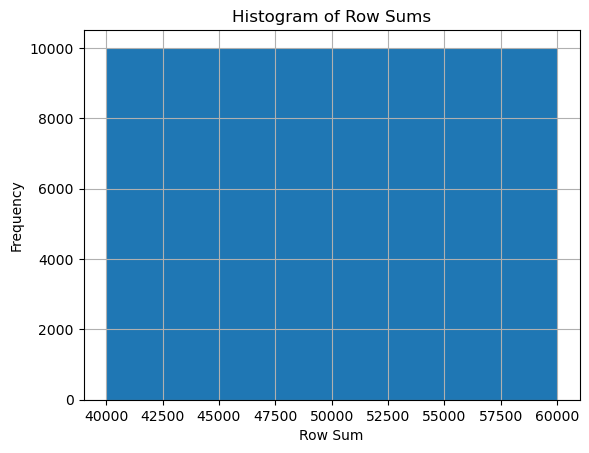

In [8]:
# Histogram of row sums. Should be even in between 40,000 and 60,000

import matplotlib.pyplot as plt

X_rounded_df.sum(axis=1).hist(bins=20)
plt.xlabel('Row Sum')
plt.ylabel('Frequency')
plt.title('Histogram of Row Sums')

plt.show()

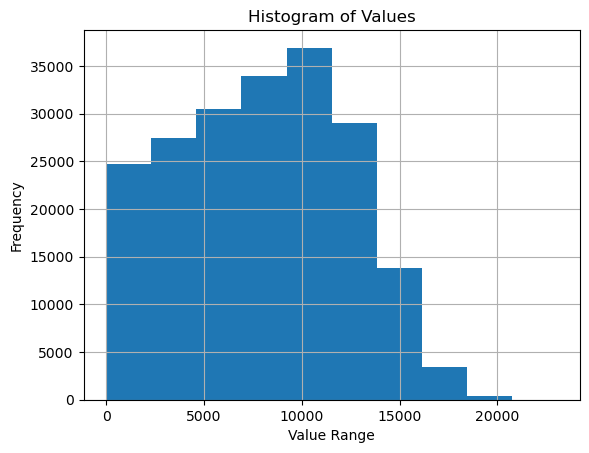

In [9]:
# Look at histogram of a city/town

X_rounded_df['Providence'].hist()
plt.title('Histogram of Values')
plt.xlabel('Value Range')
plt.ylabel('Frequency')
plt.show()

# Adding more samples

This below code shows how more samples can be easily added if needed, which is one of the primary benefits of using Sobol sequences. 

In [12]:
# Adding the next X amount of rows correctly. This was not used in generating samples, but could be leveraged in future
# if more samples were desired. 

sampler = Sobol(d=DIM + 1, scramble=True, seed=42)
sampler.fast_forward(50000)
samples_next = sampler.random(50000)

Would then need to concat the original samples table with "samples_next" to obtain updated DataFrame. 

---

**Next:** the 200,000 allocation vectors saved to `data/generated/naloxone_kit_distributions.csv`
are each run through the actual microsimulation (parallelized on an HPC cluster
via SLURM) to get real projected death counts. That step happens outside this
repo — see `02_obtain_simulation_outputs.ipynb` for how those results get
combined once they come back.